In [4]:
import os
import zipfile
import numpy as np
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.utils import (
    image_dataset_from_directory,
)  # reemplaza ImageDataGenerator.flow_from_directory
from tensorflow.keras.utils import (
    load_img,
    img_to_array,
)  # reemplaza image.load_img e image.img_to_array

In [9]:
# Extracción del dataset
local_zip = r"C:\Users\panch\Documents\Anahuac\Semestre 8\Procesamiento Inteligente de Datos\train.zip"
zip_ref = zipfile.ZipFile(local_zip, "r")
zip_ref.extractall(
    r"C:\Users\panch\Documents\Anahuac\Semestre 8\Procesamiento Inteligente de Datos"
)
zip_ref.close()

base_dir = r"C:\Users\panch\Documents\Anahuac\Semestre 8\Procesamiento Inteligente de Datos\cats_and_dogs_small"

In [6]:
# Definición de directorios
base_dir = "cats_and_dogs_small"
train_dir = os.path.join(base_dir, "train")
validation_dir = os.path.join(base_dir, "validation")
test_dir = os.path.join(base_dir, "test")

# Subdirectorios de entrenamiento
train_cats_dir = os.path.join(train_dir, "cats")
train_dogs_dir = os.path.join(train_dir, "dogs")

# Subdirectorios de validación
validation_cats_dir = os.path.join(validation_dir, "cats")
validation_dogs_dir = os.path.join(validation_dir, "dogs")

# Subdirectorios de test
test_cats_dir = os.path.join(test_dir, "cats")
test_dogs_dir = os.path.join(test_dir, "dogs")

In [7]:
# Verificación del dataset
train_cat_fnames = os.listdir(train_cats_dir)
train_dog_fnames = os.listdir(train_dogs_dir)
validation_cat_fnames = os.listdir(validation_cats_dir)
validation_dog_fnames = os.listdir(validation_dogs_dir)
test_cat_fnames = os.listdir(test_cats_dir)
test_dog_fnames = os.listdir(test_dogs_dir)

print("Primeros 5 archivos — train cats     :", train_cat_fnames[:5])
print("Primeros 5 archivos — train dogs     :", train_dog_fnames[:5])
print("Primeros 5 archivos — val cats       :", validation_cat_fnames[:5])
print("Primeros 5 archivos — val dogs       :", validation_dog_fnames[:5])
print("Primeros 5 archivos — test cats      :", test_cat_fnames[:5])
print("Primeros 5 archivos — test dogs      :", test_dog_fnames[:5])

print("\ntotal training cat images   :", len(os.listdir(train_cats_dir)))
print("total training dog images   :", len(os.listdir(train_dogs_dir)))
print("total validation cat images :", len(os.listdir(validation_cats_dir)))
print("total validation dog images :", len(os.listdir(validation_dogs_dir)))
print("total test cat images       :", len(os.listdir(test_cats_dir)))
print("total test dog images       :", len(os.listdir(test_dogs_dir)))

FileNotFoundError: [WinError 3] El sistema no puede encontrar la ruta especificada: 'cats_and_dogs_small\\train\\cats'

In [ ]:
# Visualización de imágenes
def print_pictures(dir, fnames):
    """Muestra las primeras 8 imágenes de un directorio en rejilla 4×4."""
    nrows, ncols = 4, 4
    pic_index = 8

    fig = plt.gcf()
    fig.set_size_inches(ncols * 4, nrows * 4)

    next_pix = [os.path.join(dir, fname) for fname in fnames[pic_index - 8 : pic_index]]

    for i, img_path in enumerate(next_pix):
        sp = plt.subplot(nrows, ncols, i + 1)
        img = mpimg.imread(img_path)
        plt.imshow(img)
        plt.axis("off")

    plt.show()


print("Figura 10.3 — Train cats")
print_pictures(train_cats_dir, train_cat_fnames)

print("Figura 10.4 — Train dogs")
print_pictures(train_dogs_dir, train_dog_fnames)

print("Figura 10.5 — Validation cats")
print_pictures(validation_cats_dir, validation_cat_fnames)

print("Figura 10.6 — Validation dogs")
print_pictures(validation_dogs_dir, validation_dog_fnames)

print("Figura 10.7 — Test cats")
print_pictures(test_cats_dir, test_cat_fnames)

print("Figura 10.8 — Test dogs")
print_pictures(test_dogs_dir, test_dog_fnames)

Número de ejemplos de entrenamiento: 60000
Número de ejemplos de prueba: 10000


Epoch 1/5
1875/1875 [==============================] - 5s 1ms/step - loss: 0.2734 - accuracy: 0.9193
Epoch 2/5
1875/1875 [==============================] - 3s 1ms/step - loss: 0.1221 - accuracy: 0.9631
Epoch 3/5
1875/1875 [==============================] - 3s 1ms/step - loss: 0.0892 - accuracy: 0.9730
Epoch 4/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.0727 - accuracy: 0.9777
Epoch 5/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.0582 - accuracy: 0.9817


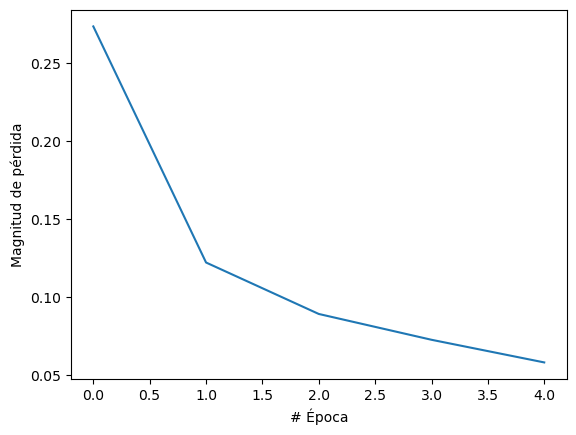

In [ ]:
# Definición del modelo CNN
model = Sequential(
    [
        Conv2D(32, (3, 3), activation="relu", input_shape=(150, 150, 3)),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation="relu"),
        MaxPooling2D(2, 2),
        Conv2D(128, (3, 3), activation="relu"),
        MaxPooling2D(2, 2),
        Conv2D(128, (3, 3), activation="relu"),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(512, activation="relu"),
        Dense(1, activation="sigmoid"),
    ]
)

model.summary()

In [ ]:
# Compilación del modelo
model.compile(
    optimizer=RMSprop(learning_rate=1e-4), loss="binary_crossentropy", metrics=["acc"]
)

313/313 [==============================] - 1s 2ms/step - loss: 0.0837 - accuracy: 0.9761
Resultado en las pruebas:  0.9761000275611877


In [ ]:
# Generadores de datos
train_datagen = ImageDataGenerator(rescale=1.0 / 255.0)
validation_datagen = ImageDataGenerator(rescale=1.0 / 255.0)
test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

train_generator = image_dataset_from_directory(
    train_dir, batch_size=20, label_mode="binary", image_size=(150, 150)
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir, batch_size=20, class_mode="binary", target_size=(150, 150)
)

test_generator = test_datagen.flow_from_directory(
    test_dir, batch_size=20, class_mode="binary", target_size=(150, 150)
)

1/1 [==============================] - 0s 80ms/step


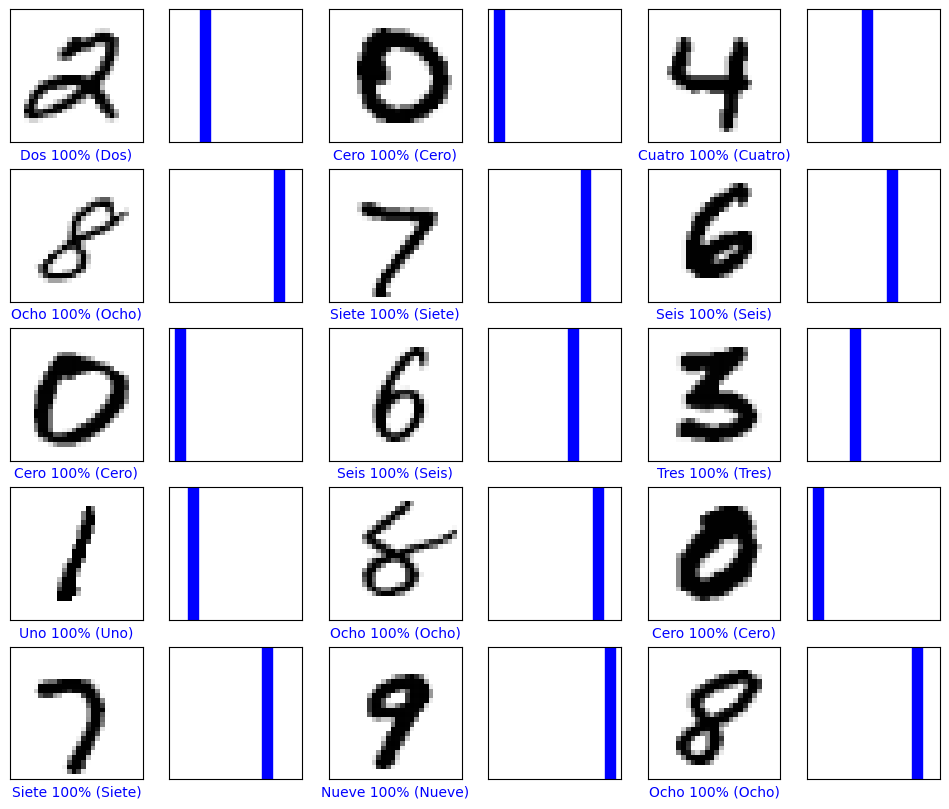

In [ ]:
# Entrenamiento del modelo
batch_size = 20
steps_per_epoch = train_generator.n // batch_size
validation_steps = validation_generator.n // batch_size

print("steps_per_epoch  :", steps_per_epoch)
print("validation_steps :", validation_steps)

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=100,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    verbose=2,
)

In [ ]:
# Visualización de curvas de entrenamiento
acc = history.history["acc"]
val_acc = history.history["val_acc"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)

# — Exactitud —
plt.plot(epochs, acc, "r--", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Training and validation accuracy")
plt.ylabel("acc")
plt.xlabel("epochs")
plt.legend()
plt.figure()

# — Pérdida —
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.ylabel("loss")
plt.xlabel("epochs")
plt.legend()
plt.show()

In [ ]:
# Evaluación sobre el conjunto de test
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)

In [ ]:
# Predicción sobre una imagen propia
path = "images.webp"
fn = os.path.basename(path)

img = load_img(path, target_size=(150, 150))
x = img_to_array(img)
x = np.expand_dims(x, axis=0)

classes = model.predict(x)
print("Probabilidad:", classes)

plt.imshow(img)
plt.axis("off")
plt.show()

if classes[0][0] > 0.5:
    print(fn + " IS A DOG")
else:
    print(fn + " IS A CAT")